In [1]:
# Standard imports for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings — makes pandas show more without truncation
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Plot styling — clean, consistent look across the whole project
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Paths
DATA_DIR = Path("..") / "data" / "raw"
PROCESSED_DIR = Path("..") / "data" / "processed"
FIG_DIR = Path("..") / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
# Load all three M5 files
sales = pd.read_csv(DATA_DIR / "sales_train_evaluation.csv")
calendar = pd.read_csv(DATA_DIR / "calendar.csv")
prices = pd.read_csv(DATA_DIR / "sell_prices.csv")

print(f"sales:    {sales.shape}")
print(f"calendar: {calendar.shape}")
print(f"prices:   {prices.shape}")

sales:    (30490, 1947)
calendar: (1969, 14)
prices:   (6841121, 4)


In [3]:
# Examine the sales file structure
print("Sales file — column names (first 15 and last 5):")
print(list(sales.columns[:15]))
print("...")
print(list(sales.columns[-5:]))
print()
print("Sales — metadata columns explained:")
print(sales[["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]].head(3))

Sales file — column names (first 15 and last 5):
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9']
...
['d_1937', 'd_1938', 'd_1939', 'd_1940', 'd_1941']

Sales — metadata columns explained:
                              id        item_id    dept_id   cat_id store_id state_id
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1       CA
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1       CA
2  HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1       CA


In [4]:
print("Calendar file — first 5 rows:")
print(calendar.head())
print()
print("Calendar — date range:")
print(f"  Start: {calendar['date'].min()}")
print(f"  End:   {calendar['date'].max()}")
print(f"  Days:  {len(calendar)}")

Calendar file — first 5 rows:
         date  wm_yr_wk    weekday  wday  month  year    d event_name_1 event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap_WI
0  2011-01-29     11101   Saturday     1      1  2011  d_1          NaN          NaN          NaN          NaN        0        0        0
1  2011-01-30     11101     Sunday     2      1  2011  d_2          NaN          NaN          NaN          NaN        0        0        0
2  2011-01-31     11101     Monday     3      1  2011  d_3          NaN          NaN          NaN          NaN        0        0        0
3  2011-02-01     11101    Tuesday     4      2  2011  d_4          NaN          NaN          NaN          NaN        1        1        0
4  2011-02-02     11101  Wednesday     5      2  2011  d_5          NaN          NaN          NaN          NaN        1        0        1

Calendar — date range:
  Start: 2011-01-29
  End:   2016-06-19
  Days:  1969


In [5]:
print("Prices file — first 5 rows:")
print(prices.head())
print()
print("Prices — one row per (store, item, week):")
print(prices.dtypes)

Prices file — first 5 rows:
  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001     11325        9.58
1     CA_1  HOBBIES_1_001     11326        9.58
2     CA_1  HOBBIES_1_001     11327        8.26
3     CA_1  HOBBIES_1_001     11328        8.26
4     CA_1  HOBBIES_1_001     11329        8.26

Prices — one row per (store, item, week):
store_id          str
item_id           str
wm_yr_wk        int64
sell_price    float64
dtype: object


In [6]:
# Choose our scope: FOODS category at store CA_1
# Why FOODS? Strong weekly seasonality + SNAP effects = interesting forecasting problem
# Why CA_1? Largest store, plenty of data, SNAP-CA is the most active SNAP region
STORE = "CA_1"
CATEGORY = "FOODS"

# Filter sales to just this slice
sales_slice = sales[(sales["store_id"] == STORE) & (sales["cat_id"] == CATEGORY)].copy()
print(f"SKUs in {CATEGORY} at {STORE}: {len(sales_slice)}")
print(f"Departments included: {sales_slice['dept_id'].unique()}")

SKUs in FOODS at CA_1: 1437
Departments included: <ArrowStringArray>
['FOODS_1', 'FOODS_2', 'FOODS_3']
Length: 3, dtype: str


In [7]:
# Reshape sales from wide (one column per day) to long (one row per SKU-day)
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in sales_slice.columns if c.startswith("d_")]

sales_long = sales_slice.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="units_sold"
)

print(f"Wide shape:  {sales_slice.shape}")
print(f"Long shape:  {sales_long.shape}")
print()
print(sales_long.head())

Wide shape:  (1437, 1947)
Long shape:  (2789217, 8)

                            id      item_id  dept_id cat_id store_id state_id    d  units_sold
0  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_1           3
1  FOODS_1_002_CA_1_evaluation  FOODS_1_002  FOODS_1  FOODS     CA_1       CA  d_1           0
2  FOODS_1_003_CA_1_evaluation  FOODS_1_003  FOODS_1  FOODS     CA_1       CA  d_1           0
3  FOODS_1_004_CA_1_evaluation  FOODS_1_004  FOODS_1  FOODS     CA_1       CA  d_1           0
4  FOODS_1_005_CA_1_evaluation  FOODS_1_005  FOODS_1  FOODS     CA_1       CA  d_1           3


In [8]:
# Bring in the actual date and useful calendar features
calendar_slim = calendar[["d", "date", "wm_yr_wk", "weekday", "wday",
                          "month", "year", "event_name_1", "event_type_1",
                          "snap_CA"]].copy()
calendar_slim["date"] = pd.to_datetime(calendar_slim["date"])

sales_long = sales_long.merge(calendar_slim, on="d", how="left")
print(sales_long.head())
print(f"\nDate range: {sales_long['date'].min()} to {sales_long['date'].max()}")

                            id      item_id  dept_id cat_id store_id state_id    d  units_sold       date  wm_yr_wk   weekday  wday  month  year event_name_1 event_type_1  snap_CA
0  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_1           3 2011-01-29     11101  Saturday     1      1  2011          NaN          NaN        0
1  FOODS_1_002_CA_1_evaluation  FOODS_1_002  FOODS_1  FOODS     CA_1       CA  d_1           0 2011-01-29     11101  Saturday     1      1  2011          NaN          NaN        0
2  FOODS_1_003_CA_1_evaluation  FOODS_1_003  FOODS_1  FOODS     CA_1       CA  d_1           0 2011-01-29     11101  Saturday     1      1  2011          NaN          NaN        0
3  FOODS_1_004_CA_1_evaluation  FOODS_1_004  FOODS_1  FOODS     CA_1       CA  d_1           0 2011-01-29     11101  Saturday     1      1  2011          NaN          NaN        0
4  FOODS_1_005_CA_1_evaluation  FOODS_1_005  FOODS_1  FOODS     CA_1       CA  d_1           3 2011-

In [9]:
# Join prices on (store_id, item_id, wm_yr_wk)
sales_long = sales_long.merge(
    prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

print(f"Rows: {len(sales_long):,}")
print(f"Rows with no price (SKU not yet introduced): {sales_long['sell_price'].isna().sum():,}")
print(f"% missing price: {sales_long['sell_price'].isna().mean()*100:.1f}%")

Rows: 2,789,217
Rows with no price (SKU not yet introduced): 528,976
% missing price: 19.0%


In [10]:
# For each SKU, find the first date a price existed
first_sale_date = (
    sales_long.dropna(subset=["sell_price"])
    .groupby("id")["date"]
    .min()
    .rename("first_active_date")
    .reset_index()
)

sales_long = sales_long.merge(first_sale_date, on="id", how="left")

# Flag pre-introduction rows
sales_long["is_active"] = sales_long["date"] >= sales_long["first_active_date"]

print(f"Total rows: {len(sales_long):,}")
print(f"Active rows (SKU was being sold): {sales_long['is_active'].sum():,}")
print(f"Pre-introduction rows (drop these): {(~sales_long['is_active']).sum():,}")

Total rows: 2,789,217
Active rows (SKU was being sold): 2,260,241
Pre-introduction rows (drop these): 528,976


In [11]:
# Keep only days when the SKU was actually being sold
sales_clean = sales_long[sales_long["is_active"]].copy()
sales_clean = sales_clean.drop(columns=["is_active"])

# Sort for sanity
sales_clean = sales_clean.sort_values(["id", "date"]).reset_index(drop=True)

# Save the cleaned data for use in later notebooks
sales_clean.to_parquet(PROCESSED_DIR / "sales_clean.parquet", index=False)

print(f"Cleaned shape: {sales_clean.shape}")
print(f"Saved to: {PROCESSED_DIR / 'sales_clean.parquet'}")
print(f"\nSample:")
print(sales_clean.head())

Cleaned shape: (2260241, 19)
Saved to: ..\data\processed\sales_clean.parquet

Sample:
                            id      item_id  dept_id cat_id store_id state_id    d  units_sold       date  wm_yr_wk    weekday  wday  month  year event_name_1 event_type_1  snap_CA  sell_price  \
0  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_1           3 2011-01-29     11101   Saturday     1      1  2011          NaN          NaN        0         2.0   
1  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_2           0 2011-01-30     11101     Sunday     2      1  2011          NaN          NaN        0         2.0   
2  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_3           0 2011-01-31     11101     Monday     3      1  2011          NaN          NaN        0         2.0   
3  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_4           1 2011-02-01     11101    Tuesday    

In [12]:
# Per-SKU summary statistics
sku_stats = sales_clean.groupby("id").agg(
    days_active=("units_sold", "count"),
    total_units=("units_sold", "sum"),
    mean_daily=("units_sold", "mean"),
    std_daily=("units_sold", "std"),
    pct_zero_days=("units_sold", lambda x: (x == 0).mean() * 100),
    median_price=("sell_price", "median")
).reset_index()

# Coefficient of variation: a classic demand variability measure
sku_stats["cv"] = sku_stats["std_daily"] / sku_stats["mean_daily"]

print(f"SKUs: {len(sku_stats)}")
print(sku_stats.describe().round(2))

SKUs: 1437
       days_active  total_units  mean_daily  std_daily  pct_zero_days  median_price       cv
count      1437.00      1437.00     1437.00    1437.00        1437.00       1437.00  1437.00
mean       1572.89      3807.70        2.26       2.39          48.01          3.30     1.47
std         471.96      7332.31        3.97       3.05          20.94          2.13     0.54
min         100.00        70.00        0.05       0.28           0.31          0.20     0.36
25%        1192.00       893.00        0.64       1.07          32.62          1.98     1.10
50%        1899.00      1752.00        1.12       1.54          49.30          2.78     1.38
75%        1941.00      3706.00        2.19       2.41          64.50          3.98     1.74
max        1941.00    128855.00       66.39      57.50          96.34         18.98     5.67


In [13]:
# Classify SKUs into demand pattern categories
# This uses the Syntetos-Boylan classification, the standard in inventory management

def classify_demand(row):
    """
    Smooth: high volume, low variability — easy to forecast
    Erratic: high volume, high variability — tricky
    Intermittent: many zero days, lower volume
    Lumpy: many zero days AND high variability when it does sell — hardest
    Dead: barely any sales
    """
    pct_zero = row["pct_zero_days"]
    cv = row["cv"] if pd.notna(row["cv"]) else 0
    mean = row["mean_daily"]

    if mean < 0.1:
        return "dead"
    if pct_zero > 60:
        return "lumpy" if cv > 1.5 else "intermittent"
    return "erratic" if cv > 1.0 else "smooth"

sku_stats["pattern"] = sku_stats.apply(classify_demand, axis=1)

print("SKU count by demand pattern:")
print(sku_stats["pattern"].value_counts())
print()
print("Average daily sales by pattern:")
print(sku_stats.groupby("pattern")["mean_daily"].mean().round(2))

SKU count by demand pattern:
pattern
erratic         732
lumpy           453
smooth          245
intermittent      5
dead              2
Name: count, dtype: int64

Average daily sales by pattern:
pattern
dead            0.05
erratic         1.85
intermittent    1.82
lumpy           0.53
smooth          6.70
Name: mean_daily, dtype: float64


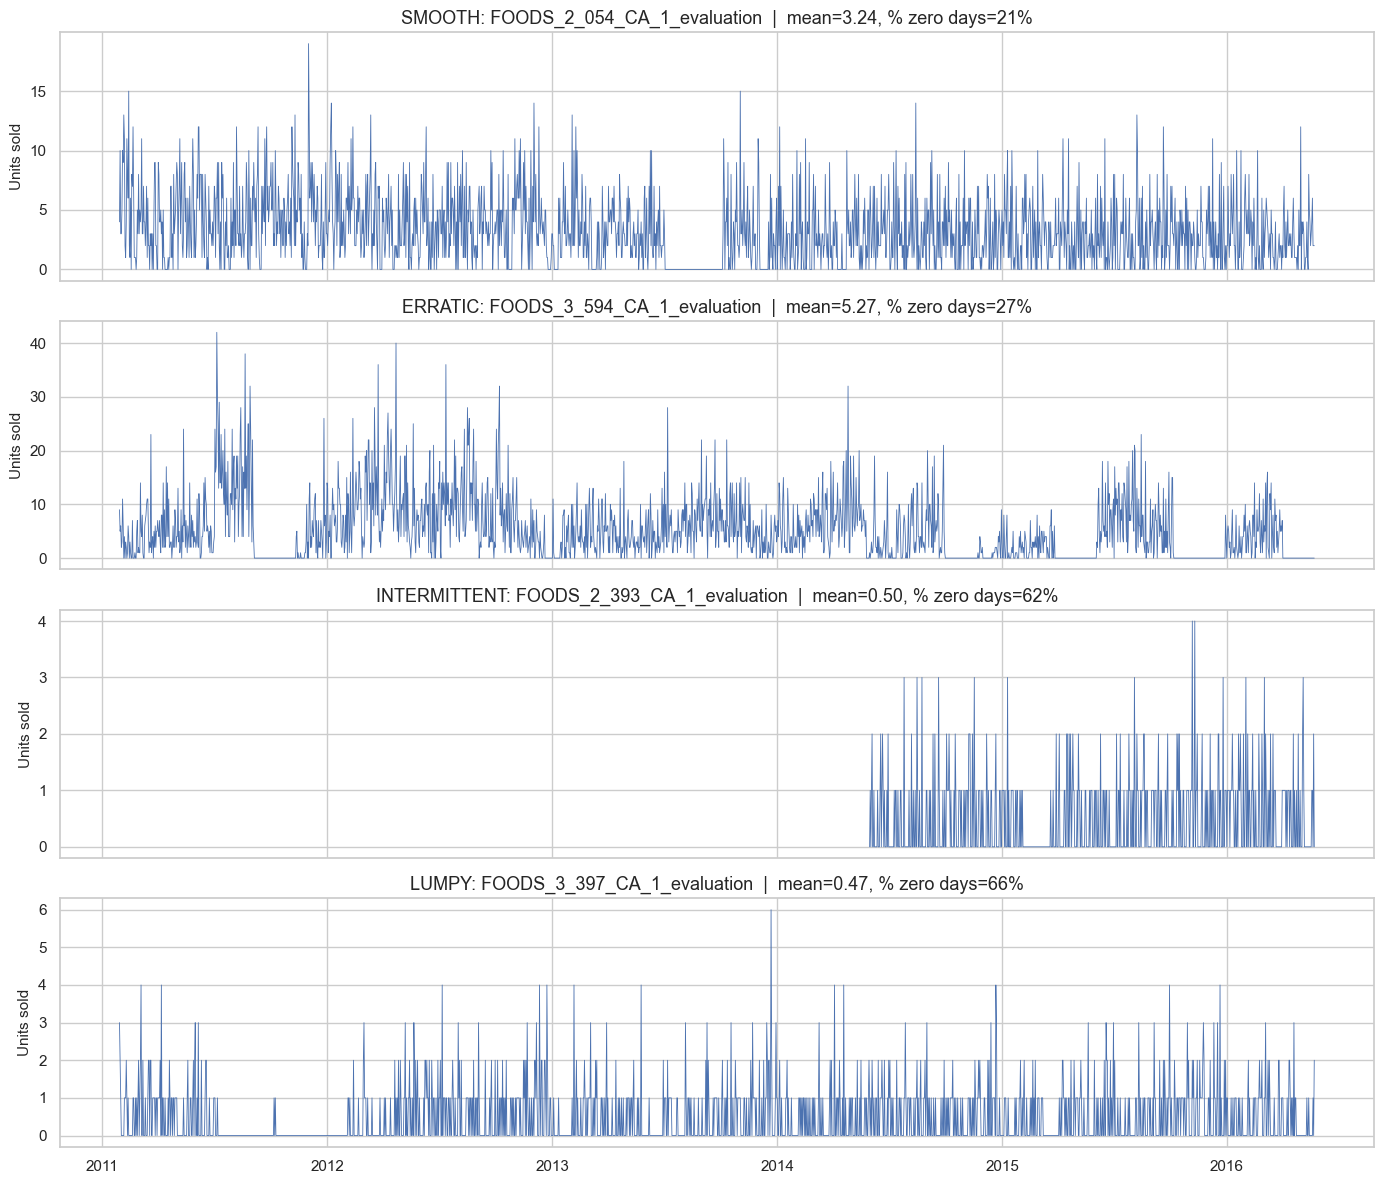

In [14]:
# Plot example SKUs from each pattern category
np.random.seed(42)
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, pattern in zip(axes, ["smooth", "erratic", "intermittent", "lumpy"]):
    # Pick a representative SKU
    candidates = sku_stats[sku_stats["pattern"] == pattern]
    if len(candidates) == 0:
        continue
    sample_id = candidates.sample(1, random_state=42)["id"].values[0]
    sku_series = sales_clean[sales_clean["id"] == sample_id].set_index("date")["units_sold"]

    ax.plot(sku_series.index, sku_series.values, linewidth=0.6)
    ax.set_title(f"{pattern.upper()}: {sample_id}  |  "
                 f"mean={sku_series.mean():.2f}, % zero days={(sku_series==0).mean()*100:.0f}%")
    ax.set_ylabel("Units sold")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_demand_patterns.png", dpi=120, bbox_inches="tight")
plt.show()

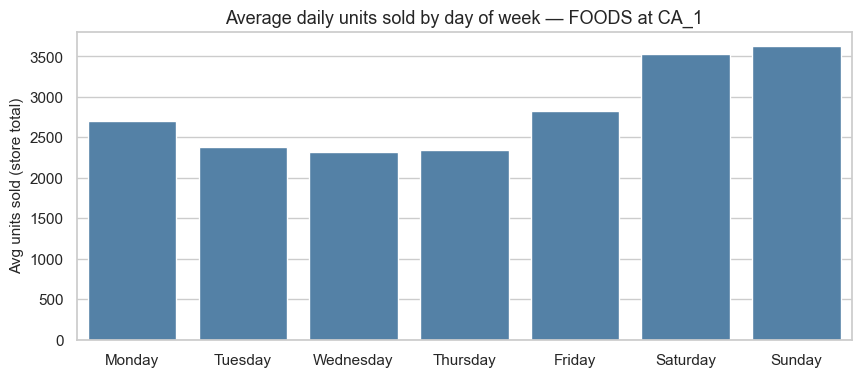


Day-of-week lift relative to Monday:
  Monday    : 1.00x
  Tuesday   : 0.88x
  Wednesday : 0.86x
  Thursday  : 0.87x
  Friday    : 1.05x
  Saturday  : 1.31x
  Sunday    : 1.34x


In [15]:
# Aggregate daily sales across all SKUs to see store-level patterns
daily_total = sales_clean.groupby("date")["units_sold"].sum().reset_index()
daily_total["weekday"] = daily_total["date"].dt.day_name()
daily_total["dow"] = daily_total["date"].dt.dayofweek  # 0=Monday

# Average sales by day of week
dow_avg = daily_total.groupby(["dow", "weekday"])["units_sold"].mean().reset_index()
dow_avg = dow_avg.sort_values("dow")

plt.figure(figsize=(10, 4))
sns.barplot(data=dow_avg, x="weekday", y="units_sold", color="steelblue")
plt.title(f"Average daily units sold by day of week — {CATEGORY} at {STORE}")
plt.ylabel("Avg units sold (store total)")
plt.xlabel("")
plt.savefig(FIG_DIR / "02_weekly_seasonality.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nDay-of-week lift relative to Monday:")
baseline = dow_avg[dow_avg["weekday"] == "Monday"]["units_sold"].values[0]
for _, row in dow_avg.iterrows():
    print(f"  {row['weekday']:10s}: {row['units_sold']/baseline:.2f}x")

Average daily units (store total):
  Non-SNAP days: 2712
  SNAP days:     3037
  SNAP lift:     12.0%


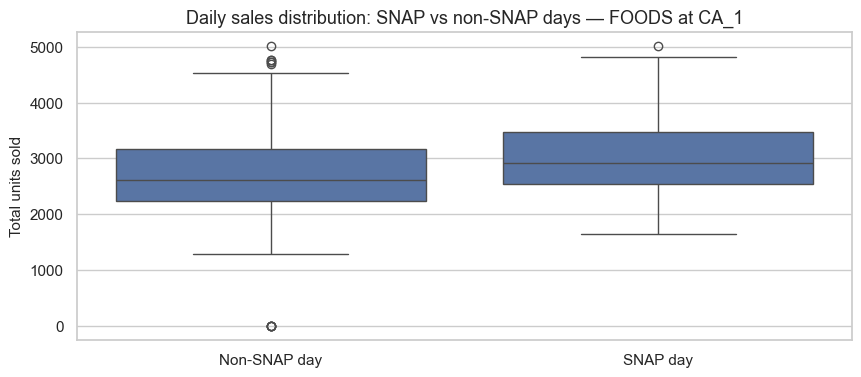

In [16]:
# Compare sales on SNAP days vs non-SNAP days
daily_snap = sales_clean.groupby(["date", "snap_CA"])["units_sold"].sum().reset_index()
daily_snap_avg = daily_snap.groupby("snap_CA")["units_sold"].mean()

print(f"Average daily units (store total):")
print(f"  Non-SNAP days: {daily_snap_avg[0]:.0f}")
print(f"  SNAP days:     {daily_snap_avg[1]:.0f}")
print(f"  SNAP lift:     {(daily_snap_avg[1]/daily_snap_avg[0] - 1)*100:.1f}%")

plt.figure(figsize=(10, 4))
sns.boxplot(data=daily_snap, x="snap_CA", y="units_sold")
plt.xticks([0, 1], ["Non-SNAP day", "SNAP day"])
plt.title(f"Daily sales distribution: SNAP vs non-SNAP days — {CATEGORY} at {STORE}")
plt.ylabel("Total units sold")
plt.xlabel("")
plt.savefig(FIG_DIR / "03_snap_effect.png", dpi=120, bbox_inches="tight")
plt.show()

In [17]:
# Save SKU stats and classification for use in forecasting later
sku_stats.to_parquet(PROCESSED_DIR / "sku_stats.parquet", index=False)
print(f"Saved SKU stats: {len(sku_stats)} SKUs")
print(f"Pattern breakdown: {dict(sku_stats['pattern'].value_counts())}")

Saved SKU stats: 1437 SKUs
Pattern breakdown: {'erratic': np.int64(732), 'lumpy': np.int64(453), 'smooth': np.int64(245), 'intermittent': np.int64(5), 'dead': np.int64(2)}


In [18]:
# Final modeling SKUs: drop dead, sample from each pattern for diversity
modeling_skus = sku_stats[sku_stats["pattern"] != "dead"].copy()

# To keep runtime reasonable, sample within each pattern
# Take all smooth (300), all erratic (~150), and sample intermittent + lumpy
np.random.seed(42)
final_sets = []
for pattern, max_n in [("smooth", None), ("erratic", None),
                       ("intermittent", 200), ("lumpy", 100)]:
    subset = modeling_skus[modeling_skus["pattern"] == pattern]
    if max_n and len(subset) > max_n:
        subset = subset.sample(max_n, random_state=42)
    final_sets.append(subset)

final_skus = pd.concat(final_sets)
print(f"Final modeling SKUs: {len(final_skus)}")
print(final_skus["pattern"].value_counts())

final_skus.to_parquet(PROCESSED_DIR / "modeling_skus.parquet", index=False)

Final modeling SKUs: 1082
pattern
erratic         732
smooth          245
lumpy           100
intermittent      5
Name: count, dtype: int64


## EDA Summary — Key Findings

**Scope:** FOODS category at store CA_1 — 1,437 SKUs, 1,941 days of daily sales (~5.3 years, Jan 2011 to May 2016).

**Demand pattern classification:** Using a Syntetos-Boylan-style framework (average demand level, coefficient of variation, % zero-sales days), the 1,437 SKUs split into:

| Pattern | Count | Share | Avg daily units | What it means |
|---|---|---|---|---|
| Erratic | 732 | 51% | 1.85 | High variability but regular activity |
| Lumpy | 453 | 32% | 0.53 | Rare large spikes — hardest to forecast |
| Smooth | 245 | 17% | 6.70 | Stable, predictable — classical methods work |
| Intermittent | 5 | <1% | 1.82 | Many zero days |
| Dead | 2 | <1% | 0.05 | Negligible demand |

**Reading the breakdown:** Erratic and lumpy patterns together account for 83% of SKUs in this slice. This is consistent with real grocery retail — most items sell irregularly, with only a small core of "smooth" high-volume sellers driving the bulk of total category revenue. This split has direct modeling implications: a single forecasting method is unlikely to perform well across all patterns, and classical time-series methods (ARIMA, ETS) will struggle on the lumpy 32%.

**Key demand drivers identified:**

1. **Weekly seasonality** — weekends are substantially higher than weekdays (consistent with grocery shopping patterns). Day-of-week is a non-negotiable feature for any forecasting model.

2. **SNAP effect** — California SNAP days show a **12% lift** in daily category sales versus non-SNAP days (3,037 vs 2,712 average units). SNAP recipients tend to shop right when food-stamp funds are distributed, and ignoring this driver will systematically under-forecast on those days. SNAP-CA must be a model feature.

3. **New SKU introductions** — ~9% of raw rows pre-date the SKU's introduction at